# Practice: Fourier Neural Operator for a 1D PDE

This notebook introduces **Fourier Neural Operator (FNO)** using a simple 1D heat equation example.

The goal is to learn the solution operator

$$
\mathcal{G}: u_0(x) \mapsto u(T,x).
$$

Here:

- \(u_0(x)\) is the initial condition.
- \(u(T,x)\) is the solution at a later time \(T\).
- The model learns this map from many examples.

This is different from a PINN.

$$
\text{PINN: } (t,x) \mapsto u(t,x)
$$

$$
\text{FNO: } u_0(x) \mapsto u(T,x)
$$

So the FNO learns a **solution operator**, not only one solution.

## 1. Problem setting

We consider the 1D heat equation:

$$
\partial_t u = \nu \partial_{xx}u,
$$

with periodic boundary condition on

$$
x\in[0,1].
$$

For each initial condition \(u_0(x)\), the PDE gives a corresponding solution \(u(T,x)\).

Therefore, the PDE defines the solution operator:

$$
\mathcal{G}: u_0(x) \mapsto u(T,x).
$$

In this notebook, we generate many pairs

$$
\{u_0^{(i)}(x), u^{(i)}(T,x)\}_{i=1}^{N}
$$

and train FNO to learn this map.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Fix random seed for reproducibility.
torch.manual_seed(0)

# Use GPU if available.
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## 2. Hyperparameters

The default setting is small enough for lecture practice.

- `n_grid`: number of spatial grid points.
- `n_train`: number of training functions.
- `n_test`: number of test functions.
- `nu`: diffusion coefficient.
- `T`: final time.

We use \(T=0.5\), not a very small time step, so that the initial condition and final solution look visibly different.

In [2]:
# -----------------------------
# Problem setting
# -----------------------------

# Number of grid points in x.
n_grid = 64

# Number of training and test samples.
n_train = 512
n_test = 128

# Heat equation parameter.
nu = 0.01

# Final time.
# We learn u0(x) -> u(T,x).
T = 0.5

## 3. Generate random initial conditions

We need many different input functions.

Here we generate smooth random initial conditions by adding sine and cosine functions:

$$u_0(x)
=
\sum_{k=1}^{K}
a_k \sin(2\pi kx)
+
b_k \cos(2\pi kx).
$$

Each sample has different random coefficients \(a_k,b_k\).

This gives many different PDE cases:

$$u_0^{(1)}(x), u_0^{(2)}(x), \dots, u_0^{(N)}(x).
$$

In [3]:
def generate_random_functions(batch_size, n_grid, max_mode=5):
    """
    Generate smooth random initial conditions.

    Output:
        u0 shape = (batch_size, n_grid)

    Each row is one function u0(x).
    """
    # Spatial grid.
    x = torch.linspace(0, 1, n_grid, device=device)

    # Container for all functions.
    u = torch.zeros(batch_size, n_grid, device=device)

    # Add low-frequency sine and cosine modes.
    # Low-frequency modes make smooth functions.
    for k in range(1, max_mode + 1):
        a = torch.randn(batch_size, 1, device=device)
        b = torch.randn(batch_size, 1, device=device)

        u += a * torch.sin(2 * np.pi * k * x)
        u += b * torch.cos(2 * np.pi * k * x)

    return u

## 4. Generate the PDE solution by FFT

For the heat equation with periodic boundary condition,

$$
\partial_t u = \nu \partial_{xx}u,
$$

the Fourier coefficients satisfy

$$
\widehat{u}(T,k)
=
\exp\left(-\nu (2\pi k)^2T\right)
\widehat{u}_0(k).
$$

So we can compute \(u(T,x)\) exactly using FFT.

This numerical solver is used only to generate training data.
During training, the FNO only sees pairs:

$$
u_0(x) \quad\longrightarrow\quad u(T,x).
$$

In [4]:
def heat_solution_fft(u0, nu=0.01, T=0.5):
    """
    Solve the periodic 1D heat equation using FFT.

    PDE:
        u_t = nu u_xx

    Input:
        u0: initial condition, shape (batch, n_grid)

    Output:
        uT: solution at time T, shape (batch, n_grid)
    """
    batch_size, n = u0.shape

    # Fourier transform of the initial condition.
    u0_hat = torch.fft.rfft(u0, dim=-1)

    # Fourier frequencies.
    # k = 0, 1, 2, ...
    k = torch.fft.rfftfreq(n, d=1.0 / n).to(device)

    # Heat equation damps high-frequency modes.
    decay = torch.exp(-nu * (2 * np.pi * k) ** 2 * T)

    # Apply the heat equation evolution in Fourier domain.
    uT_hat = u0_hat * decay

    # Transform back to physical space.
    uT = torch.fft.irfft(uT_hat, n=n, dim=-1)

    return uT

## 5. Prepare training and test data

The training set is

$$
\{u_0^{(i)}(x),u^{(i)}(T,x)\}_{i=1}^{N}.
$$

The tensor shapes are:

$$
u_0: (N, n_{\mathrm{grid}}, 1),
$$

$$
u_T: (N, n_{\mathrm{grid}}, 1).
$$

The final dimension is the channel dimension.

In [5]:
# -----------------------------
# Generate training data
# -----------------------------
u0_train = generate_random_functions(n_train, n_grid)
uT_train = heat_solution_fft(u0_train, nu=nu, T=T)

# -----------------------------
# Generate test data
# -----------------------------
u0_test = generate_random_functions(n_test, n_grid)
uT_test = heat_solution_fft(u0_test, nu=nu, T=T)

# Add channel dimension.
# FNO input shape: (batch, n_grid, channel)
u0_train = u0_train[..., None]
uT_train = uT_train[..., None]

u0_test = u0_test[..., None]
uT_test = uT_test[..., None]

print("u0_train shape:", u0_train.shape)
print("uT_train shape:", uT_train.shape)
print("u0_test shape:", u0_test.shape)
print("uT_test shape:", uT_test.shape)

u0_train shape: torch.Size([512, 64, 1])
uT_train shape: torch.Size([512, 64, 1])
u0_test shape: torch.Size([128, 64, 1])
uT_test shape: torch.Size([128, 64, 1])


## 6. Visualize the dataset

Before training, we check what the operator-learning data look like.

Each row should be interpreted as

$$
u_0^{(i)}(x) \mapsto u^{(i)}(T,x).
$$

Because the heat equation smooths the initial condition, \(u(T,x)\) is smoother than \(u_0(x)\).

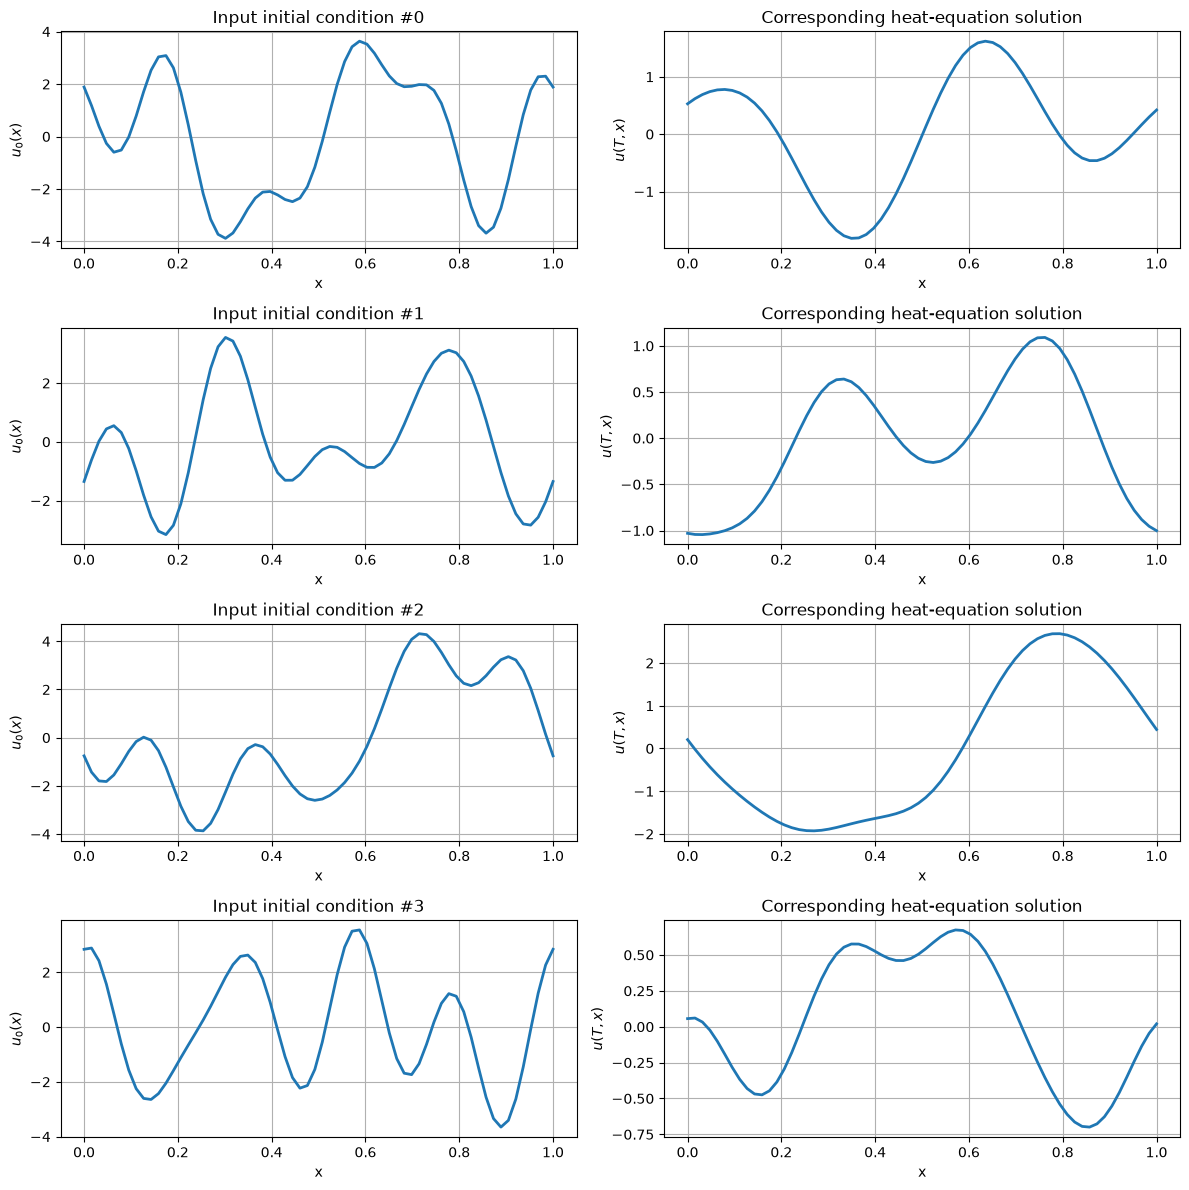

In [6]:
def plot_dataset_examples(u0, uT, sample_ids=[0, 1, 2, 3]):
    """
    Plot several input-output pairs from the dataset.
    """
    x_cpu = torch.linspace(0, 1, u0.shape[1]).cpu().numpy()

    n_samples = len(sample_ids)
    plt.figure(figsize=(12, 3 * n_samples))

    for row, sample_id in enumerate(sample_ids):
        input_function = u0[sample_id, :, 0].detach().cpu().numpy()
        output_solution = uT[sample_id, :, 0].detach().cpu().numpy()

        # Input initial condition.
        plt.subplot(n_samples, 2, 2 * row + 1)
        plt.plot(x_cpu, input_function, linewidth=2)
        plt.xlabel("x")
        plt.ylabel(r"$u_0(x)$")
        plt.title(f"Input initial condition #{sample_id}")
        plt.grid(True)

        # Corresponding PDE solution.
        plt.subplot(n_samples, 2, 2 * row + 2)
        plt.plot(x_cpu, output_solution, linewidth=2)
        plt.xlabel("x")
        plt.ylabel(r"$u(T,x)$")
        plt.title("Corresponding heat-equation solution")
        plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_dataset_examples(u0_train, uT_train, sample_ids=[0, 1, 2, 3])

## 7. Spectral convolution layer

The main FNO layer works in the Fourier domain.

The idea is:

$$
v(x)
\overset{\mathcal{F}}{\longrightarrow}
\widehat{v}(k)
\overset{\text{learn}}{\longrightarrow}
R_\theta(k)\widehat{v}(k)
\overset{\mathcal{F}^{-1}}{\longrightarrow}
v'(x).
$$

This is connected to integral operators because convolution-type integral operators become multiplication in Fourier space.

In practice, FNO learns only low-frequency modes:

$$
|k|\leq K.
$$

This is efficient and works well for many smooth PDE solution functions.

In [7]:
class SpectralConv1D(nn.Module):
    """
    1D spectral convolution layer.

    This layer:
        1. transforms the hidden function to Fourier domain,
        2. modifies low-frequency Fourier modes by learnable complex weights,
        3. transforms back to physical domain.
    """

    def __init__(self, in_channels, out_channels, modes):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels

        # Number of Fourier modes to keep.
        # Higher modes are set to zero.
        self.modes = modes

        # Complex-valued learnable weights for Fourier modes.
        # Shape:
        #   (input channels, output channels, number of modes)
        scale = 1.0 / (in_channels * out_channels)
        self.weights = nn.Parameter(
            scale * torch.randn(
                in_channels,
                out_channels,
                modes,
                dtype=torch.cfloat
            )
        )

    def forward(self, x):
        """
        Input:
            x shape = (batch, channels, n_grid)

        Output:
            x shape = (batch, out_channels, n_grid)
        """
        batch_size, channels, n = x.shape

        # 1. Fourier transform.
        # rfft is used because the input is real-valued.
        x_ft = torch.fft.rfft(x, dim=-1)

        # 2. Allocate output Fourier coefficients.
        out_ft = torch.zeros(
            batch_size,
            self.out_channels,
            x_ft.shape[-1],
            device=x.device,
            dtype=torch.cfloat
        )

        # 3. Learn the transformation only for low-frequency modes.
        # Einstein summation:
        #   x_ft:   (batch, in_channels, modes)
        #   weights:(in_channels, out_channels, modes)
        #   output: (batch, out_channels, modes)
        out_ft[:, :, :self.modes] = torch.einsum(
            "bim,iom->bom",
            x_ft[:, :, :self.modes],
            self.weights
        )

        # 4. Inverse Fourier transform back to physical space.
        x = torch.fft.irfft(out_ft, n=n, dim=-1)

        return x

## 8. FNO model architecture

The FNO model has three parts:

$$
\text{lifting}
\quad\longrightarrow\quad
\text{Fourier operator layers}
\quad\longrightarrow\quad
\text{projection}.
$$

### Lifting

At each grid point, the input is

$$
[u_0(x), x].
$$

We include the coordinate \(x\) because it tells the model the spatial location.

### Fourier operator layers

These layers learn global interactions in Fourier space.

### Projection

The hidden representation is mapped back to the output function \(u(T,x)\).

In [8]:
class FNO1D(nn.Module):
    """
    1D Fourier Neural Operator.

    It learns the map:
        u0(x) -> u(T,x)
    """

    def __init__(self, modes=16, width=32):
        super().__init__()

        self.modes = modes
        self.width = width

        # -----------------------------
        # Lifting layer
        # -----------------------------
        # Input channels:
        #   1. u0(x)
        #   2. coordinate x
        #
        # Output:
        #   hidden feature of dimension width
        self.lift = nn.Linear(2, width)

        # -----------------------------
        # Fourier operator layers
        # -----------------------------
        self.conv0 = SpectralConv1D(width, width, modes)
        self.conv1 = SpectralConv1D(width, width, modes)
        self.conv2 = SpectralConv1D(width, width, modes)
        self.conv3 = SpectralConv1D(width, width, modes)

        # Pointwise linear transformations.
        # These are local transformations at each x.
        self.w0 = nn.Conv1d(width, width, 1)
        self.w1 = nn.Conv1d(width, width, 1)
        self.w2 = nn.Conv1d(width, width, 1)
        self.w3 = nn.Conv1d(width, width, 1)

        # -----------------------------
        # Projection layer
        # -----------------------------
        # Convert hidden features back to scalar output u(T,x).
        self.project = nn.Sequential(
            nn.Linear(width, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

    def forward(self, u0):
        """
        Input:
            u0 shape = (batch, n_grid, 1)

        Output:
            prediction shape = (batch, n_grid, 1)
        """
        batch_size, n, _ = u0.shape

        # Create coordinate grid x in [0,1].
        grid = torch.linspace(0, 1, n, device=u0.device)
        grid = grid[None, :, None].repeat(batch_size, 1, 1)

        # -----------------------------
        # 1. Lifting
        # -----------------------------
        # Concatenate function value and coordinate:
        #   [u0(x), x]
        x = torch.cat([u0, grid], dim=-1)

        # Map from 2 channels to width channels.
        x = self.lift(x)                  # (batch, n_grid, width)

        # SpectralConv1D expects channel-first format.
        x = x.permute(0, 2, 1)            # (batch, width, n_grid)

        # -----------------------------
        # 2. Fourier operator layers
        # -----------------------------
        # Each layer has:
        #   nonlocal Fourier transform part + local pointwise part.
        x = F.gelu(self.conv0(x) + self.w0(x))
        x = F.gelu(self.conv1(x) + self.w1(x))
        x = F.gelu(self.conv2(x) + self.w2(x))
        x = F.gelu(self.conv3(x) + self.w3(x))

        # Return to pointwise format.
        x = x.permute(0, 2, 1)            # (batch, n_grid, width)

        # -----------------------------
        # 3. Projection
        # -----------------------------
        out = self.project(x)             # (batch, n_grid, 1)

        return out

## 9. Training objective

We train FNO by supervised operator learning.

Given training pairs

$$
\{u_0^{(i)}(x), u^{(i)}(T,x)\}_{i=1}^{N},
$$

we minimize

$$
\mathcal{L}(\theta)
=
\frac{1}{N}
\sum_{i=1}^{N}
\left\|
\mathcal{G}_\theta(u_0^{(i)}) - u^{(i)}(T)
\right\|^2.
$$

This is data-driven training.

Unlike PINN, there is no PDE residual in this basic FNO example.

In [9]:
def relative_l2_error(pred, true):
    """
    Compute relative L2 error for each sample.

    pred, true shape:
        (batch, n_grid, 1)
    """
    pred = pred.reshape(pred.shape[0], -1)
    true = true.reshape(true.shape[0], -1)

    return torch.norm(pred - true, dim=1) / torch.norm(true, dim=1)


def train_model(model, train_x, train_y, test_x, test_y,
                epochs=300, batch_size=64, lr=1e-3):
    """
    Train FNO by minimizing MSE between predicted and true solution functions.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    n_train = train_x.shape[0]

    train_loss_history = []
    test_loss_history = []
    test_rel_l2_history = []

    for epoch in range(epochs):
        model.train()

        # Shuffle training samples.
        perm = torch.randperm(n_train, device=device)

        total_loss = 0.0
        num_batches = 0

        for i in range(0, n_train, batch_size):
            idx = perm[i:i + batch_size]

            batch_x = train_x[idx]
            batch_y = train_y[idx]

            # Forward pass:
            #   input function u0(x) -> predicted solution u(T,x)
            pred = model(batch_x)

            # Data loss.
            loss = mse(pred, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        train_loss = total_loss / num_batches

        # Evaluation on test functions.
        model.eval()
        with torch.no_grad():
            test_pred = model(test_x)
            test_loss = mse(test_pred, test_y).item()
            test_rel_l2 = relative_l2_error(test_pred, test_y).mean().item()

        train_loss_history.append(train_loss)
        test_loss_history.append(test_loss)
        test_rel_l2_history.append(test_rel_l2)

        if epoch % 50 == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"train MSE: {train_loss:.6f} | "
                f"test MSE: {test_loss:.6f} | "
                f"test rel L2: {test_rel_l2:.6f}"
            )

    return train_loss_history, test_loss_history, test_rel_l2_history

## 10. Train FNO

Now we train the FNO model.

The model sees many different input functions \(u_0(x)\) and learns to predict their corresponding solutions \(u(T,x)\).

In [10]:
# Create the FNO model.
fno = FNO1D(modes=16, width=32).to(device)

# Train the model.
train_loss_history, test_loss_history, test_rel_l2_history = train_model(
    fno,
    u0_train,
    uT_train,
    u0_test,
    uT_test,
    epochs=300,
    batch_size=64,
    lr=1e-3
)

Epoch    0 | train MSE: 0.880843 | test MSE: 0.827112 | test rel L2: 0.972077
Epoch   50 | train MSE: 0.000644 | test MSE: 0.000626 | test rel L2: 0.028237
Epoch  100 | train MSE: 0.000059 | test MSE: 0.000091 | test rel L2: 0.011324
Epoch  150 | train MSE: 0.000023 | test MSE: 0.000041 | test rel L2: 0.007643
Epoch  200 | train MSE: 0.000013 | test MSE: 0.000026 | test rel L2: 0.006006
Epoch  250 | train MSE: 0.000009 | test MSE: 0.000019 | test rel L2: 0.005154


## 11. Visualize training history

The training loss and test loss should decrease during training.

The relative \(L^2\) error is useful because it measures the error relative to the size of the true solution.

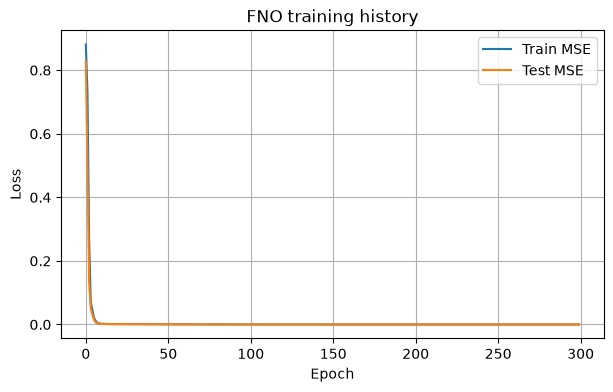

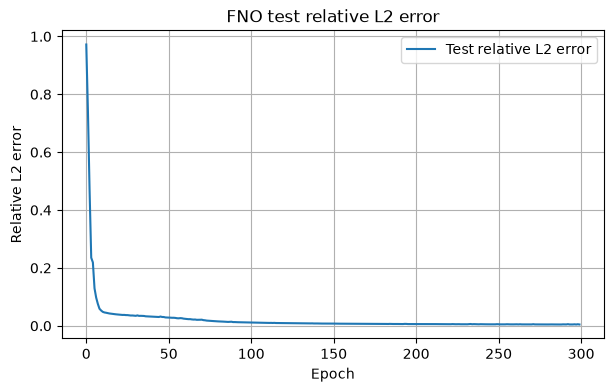

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(train_loss_history, label="Train MSE")
plt.plot(test_loss_history, label="Test MSE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("FNO training history")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(test_rel_l2_history, label="Test relative L2 error")
plt.xlabel("Epoch")
plt.ylabel("Relative L2 error")
plt.title("FNO test relative L2 error")
plt.legend()
plt.grid(True)
plt.show()

## 12. Visualize operator learning results

This is the most important visualization.

We want to show:

$$
u_0^{(1)}(x) \mapsto u^{(1)}(T,x),
$$

$$
u_0^{(2)}(x) \mapsto u^{(2)}(T,x),
$$

and so on.

Different input functions should produce different solution functions.

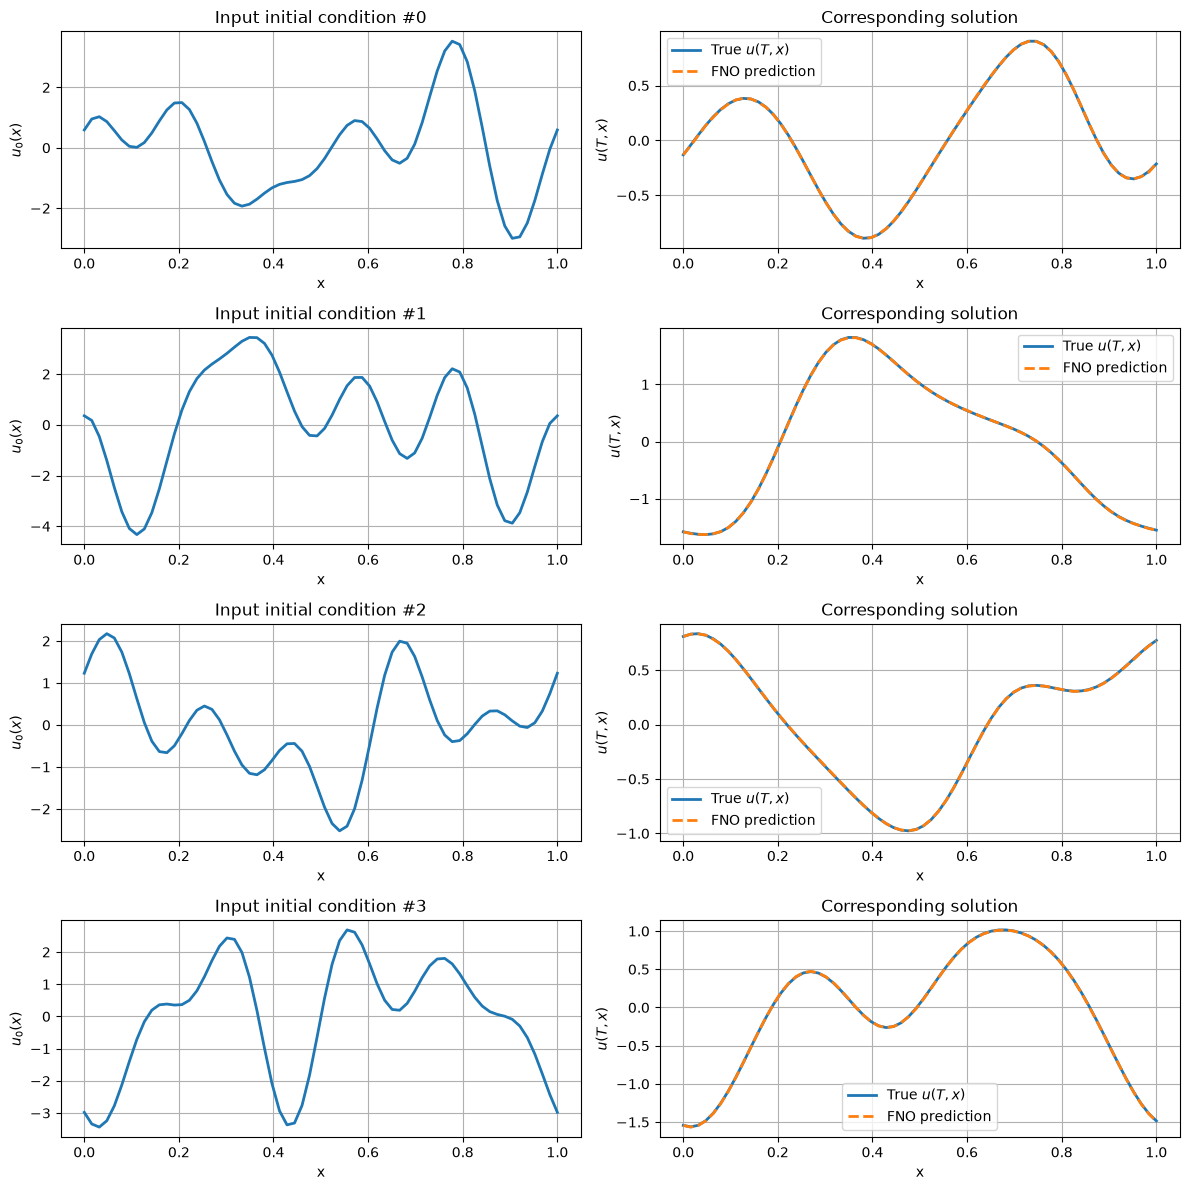

In [12]:
def plot_multiple_operator_results(model, test_x, test_y,
                                   sample_ids=[0, 1, 2, 3],
                                   name="FNO"):
    """
    Show that different initial conditions produce different solutions.

    Each row shows:
        left:  input initial condition u0(x)
        right: true solution u(T,x) and model prediction
    """
    model.eval()

    n_samples = len(sample_ids)
    x_cpu = torch.linspace(0, 1, test_x.shape[1]).cpu().numpy()

    plt.figure(figsize=(12, 3 * n_samples))

    for row, sample_id in enumerate(sample_ids):
        with torch.no_grad():
            pred = model(test_x[sample_id:sample_id + 1])

        u0 = test_x[sample_id, :, 0].detach().cpu().numpy()
        true_uT = test_y[sample_id, :, 0].detach().cpu().numpy()
        pred_uT = pred[0, :, 0].detach().cpu().numpy()

        # Input function.
        plt.subplot(n_samples, 2, 2 * row + 1)
        plt.plot(x_cpu, u0, linewidth=2)
        plt.xlabel("x")
        plt.ylabel(r"$u_0(x)$")
        plt.title(f"Input initial condition #{sample_id}")
        plt.grid(True)

        # Corresponding output function.
        plt.subplot(n_samples, 2, 2 * row + 2)
        plt.plot(x_cpu, true_uT, "-", linewidth=2, label=r"True $u(T,x)$")
        plt.plot(x_cpu, pred_uT, "--", linewidth=2, label=f"{name} prediction")
        plt.xlabel("x")
        plt.ylabel(r"$u(T,x)$")
        plt.title("Corresponding solution")
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_multiple_operator_results(
    fno,
    u0_test,
    uT_test,
    sample_ids=[0, 1, 2, 3],
    name="FNO"
)

## 13. Visualize one prediction with error

For one test example, we plot:

1. the input initial condition,
2. the true solution,
3. the FNO prediction,
4. the pointwise prediction error.

This helps us see where the operator prediction is accurate or inaccurate.

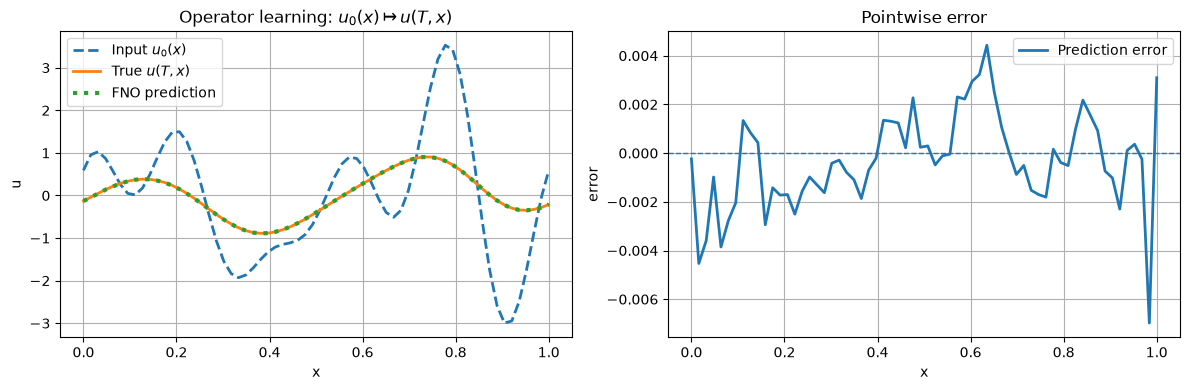

In [13]:
def plot_one_prediction_with_error(model, test_x, test_y,
                                   sample_id=0,
                                   name="FNO"):
    """
    Visualize one test prediction and pointwise error.
    """
    model.eval()

    with torch.no_grad():
        pred = model(test_x[sample_id:sample_id + 1])

    x_cpu = torch.linspace(0, 1, test_x.shape[1]).cpu().numpy()

    u0 = test_x[sample_id, :, 0].detach().cpu().numpy()
    true_uT = test_y[sample_id, :, 0].detach().cpu().numpy()
    pred_uT = pred[0, :, 0].detach().cpu().numpy()

    error = pred_uT - true_uT

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(x_cpu, u0, "--", linewidth=2, label=r"Input $u_0(x)$")
    plt.plot(x_cpu, true_uT, "-", linewidth=2, label=r"True $u(T,x)$")
    plt.plot(x_cpu, pred_uT, ":", linewidth=3, label=f"{name} prediction")
    plt.xlabel("x")
    plt.ylabel("u")
    plt.title(r"Operator learning: $u_0(x)\mapsto u(T,x)$")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(x_cpu, error, linewidth=2, label="Prediction error")
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.xlabel("x")
    plt.ylabel("error")
    plt.title("Pointwise error")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_one_prediction_with_error(
    fno,
    u0_test,
    uT_test,
    sample_id=0,
    name="FNO"
)